# 5. Efek Lebaran: modal mie ayam naik ga ya?

Pertanyaan notebook ini: apakah biaya bahan mie ayam naik menjelang Lebaran, dan kalau iya seberapa besar?

**Bagian 1 (hari ini):** siapkan data biaya per porsi dan tandai bulan Lebaran.
**Bagian 2 (berikutnya):** bandingkan sebelum, saat, dan sesudah Lebaran.

## Langkah 1: Muat data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/kaggle/input/datasets/samuelgeraldo/bedah-mie-ayam-pakai-data-bukan-sumpit/harga_pangan_bersih.csv"
df = pd.read_csv(PATH)
df.head()

,bulan,komoditas,harga_rp
0,2021-01,Bawang Merah Ukuran Sedang,NaN
1,2021-02,Bawang Merah Ukuran Sedang,31450.0
2,2021-03,Bawang Merah Ukuran Sedang,34250.0
3,2021-04,Bawang Merah Ukuran Sedang,34400.0
4,2021-05,Bawang Merah Ukuran Sedang,32950.0


Format datanya *long*: satu baris per bulan per komoditas. Untuk menghitung biaya per bulan, lebih enak kalau tiap komoditas jadi satu kolom (format *wide*). Itu fungsi `pivot`.

In [2]:
wide = df.pivot(index="bulan", columns="komoditas", values="harga_rp")
wide.index = pd.to_datetime(wide.index)
wide.head()

komoditas,Bawang Merah Ukuran Sedang,Bawang Putih Ukuran Sedang,Daging Ayam Ras Segar,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2
bulan,,,,,
2021-01-01,NaN,NaN,NaN,NaN,NaN
2021-02-01,31450.0,27900.0,33550.0,15100.0,14500.0
2021-03-01,34250.0,29450.0,34300.0,15150.0,14550.0
2021-04-01,34400.0,29900.0,34750.0,15300.0,14750.0
2021-05-01,32950.0,30150.0,36000.0,15500.0,14950.0


## Langkah 2: Isi bulan kosong dan buang Okt 2026
Sama seperti Notebook 2: interpolasi untuk bulan kosong, `limit_direction='both'` supaya Jan 2021 (di ujung awal) ikut terisi.

In [3]:
wide = wide.interpolate(limit_direction="both")
wide = wide[wide.index < "2026-10-01"]   # Okt 2026 belum utuh
wide.isna().sum().sum()   # harus 0

np.int64(0)

## Langkah 3: Hitung biaya per porsi
Rumus: harga per kg × gram resep ÷ 1000. Minyak goreng satuannya liter, jadi 20 ml = harga × 20 ÷ 1000.

Di data ada dua merek minyak goreng. Di sini keduanya dirata-rata. **Cek:** samakan dengan cara yang kamu pakai di Notebook 2, supaya angkanya konsisten (total Sep 2026 harus ±Rp 3.613).

In [4]:
minyak = wide[["Minyak Goreng Kemasan Bermerk 1", "Minyak Goreng Kemasan Bermerk 2"]].mean(axis=1)

biaya = pd.DataFrame({
    "ayam":         wide["Daging Ayam Ras Segar"]     * 60 / 1000,
    "bawang_merah": wide["Bawang Merah Ukuran Sedang"] * 10 / 1000,
    "bawang_putih": wide["Bawang Putih Ukuran Sedang"] *  5 / 1000,
    "minyak":       minyak * 20 / 1000,
})
biaya["total"] = biaya.sum(axis=1)
biaya["total"].loc[["2021-01-01", "2026-09-01"]]

bulan
2021-01-01    2763.00
2026-09-01    3613.25
Name: total, dtype: float64

## Langkah 4: Tandai Lebaran
Tanggal Idul Fitri tiap tahun. Kita ambil bulannya saja karena datanya bulanan.

In [5]:
lebaran = pd.to_datetime(pd.Series({
    2021: "2021-05-13", 2022: "2022-05-02", 2023: "2023-04-22",
    2024: "2024-04-10", 2025: "2025-03-31", 2026: "2026-03-20",
}))
lebaran_bulan = [d.to_period("M").to_timestamp() for d in lebaran]
lebaran_bulan

[Timestamp('2021-05-01 00:00:00'),
 Timestamp('2022-05-01 00:00:00'),
 Timestamp('2023-04-01 00:00:00'),
 Timestamp('2024-04-01 00:00:00'),
 Timestamp('2025-03-01 00:00:00'),
 Timestamp('2026-03-01 00:00:00')]

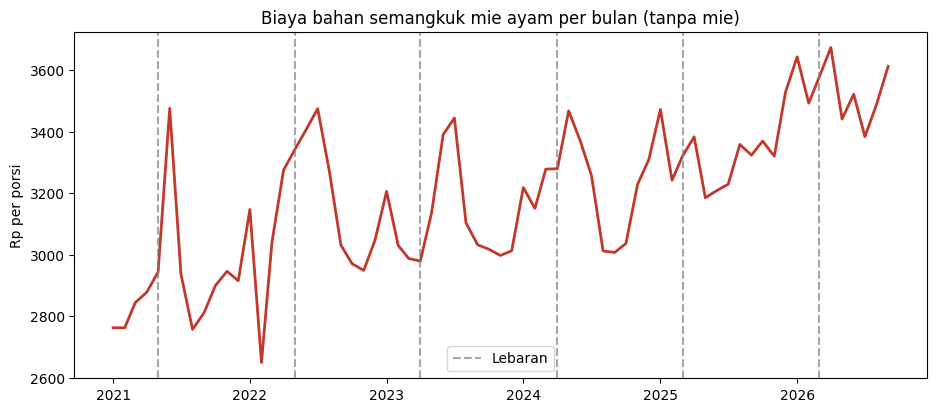

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(biaya.index, biaya["total"], color="#c0392b", lw=2)
for i, b in enumerate(lebaran_bulan):
    ax.axvline(b, color="gray", ls="--", alpha=.7, label="Lebaran" if i == 0 else None)
ax.set_title("Biaya bahan semangkuk mie ayam per bulan (tanpa mie)")
ax.set_ylabel("Rp per porsi")
ax.legend()
plt.show()

## Bagian 2: Bandingkan sebelum, saat, dan sesudah Lebaran

Dua hal yang harus diatasi:
1. **Lebaran maju ±11 hari tiap tahun**, jadi kita tidak membandingkan bulan kalender. Tiap bulan diberi label *jarak dari Lebaran*: 0 = bulan Lebaran, -1 = sebulan sebelum, +1 = sebulan sesudah.
2. **Harga naik terus (30,8% dalam 5 tahun).** Kalau memakai harga mentah, bulan Lebaran 2026 pasti kelihatan "lebih mahal" dari 2021. Jadi yang dibandingkan adalah **perubahan % dari bulan sebelumnya**. Tren naik jangka panjang ikut masuk ke pembanding (bulan biasa), jadi efek khas Lebaran lebih terlihat.

In [7]:
perubahan = biaya.pct_change() * 100          # % perubahan dibanding bulan sebelumnya
perubahan = perubahan.drop(pd.Timestamp("2021-02-01"))   # Jan 2021 hasil isian, jadi perubahan Feb 2021 palsu (0%)
perubahan = perubahan.dropna()

def jarak_ke_lebaran(tgl):
    """Selisih bulan ke Lebaran terdekat. 0 = bulan Lebaran, -1 = sebulan sebelum, +1 = sebulan sesudah."""
    selisih = [(tgl.year - b.year) * 12 + tgl.month - b.month for b in lebaran_bulan]
    return min(selisih, key=abs)

perubahan["jarak"] = [jarak_ke_lebaran(t) for t in perubahan.index]
perubahan[["total", "jarak"]].head(10)

,total,jarak
bulan,,
2021-03-01,2.958740,-2
2021-04-01,1.203972,-1
2021-05-01,2.283779,0
2021-06-01,18.066050,1
2021-07-01,-15.510175,2
2021-08-01,-6.119149,3
2021-09-01,1.985314,4
2021-10-01,3.128889,5
2021-11-01,1.594553,6


In [8]:
jendela = perubahan[perubahan["jarak"].between(-3, 3)]      # 3 bulan sebelum sampai 3 bulan sesudah
di_luar = perubahan[~perubahan["jarak"].between(-3, 3)]    # bulan "biasa" sebagai pembanding

baseline = di_luar["total"].mean()
tabel = jendela.groupby("jarak")["total"].agg(rata2="mean", n="count").round(2)
print(f"Rata-rata perubahan bulan biasa: {baseline:.2f}% per bulan")
tabel

Rata-rata perubahan bulan biasa: -0.01% per bulan


,rata2,n
jarak,,
-3,1.00,5
-2,3.05,6
-1,0.14,6
0,1.48,6
1,5.94,6
2,-3.40,6
3,-1.77,6


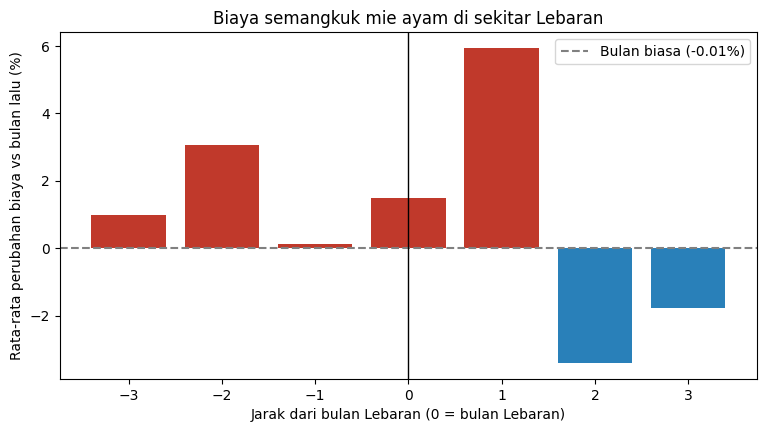

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
warna = ["#c0392b" if v > 0 else "#2980b9" for v in tabel["rata2"]]
ax.bar(tabel.index, tabel["rata2"], color=warna)
ax.axhline(baseline, color="gray", ls="--", label=f"Bulan biasa ({baseline:.2f}%)")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Jarak dari bulan Lebaran (0 = bulan Lebaran)")
ax.set_ylabel("Rata-rata perubahan biaya vs bulan lalu (%)")
ax.set_title("Biaya semangkuk mie ayam di sekitar Lebaran")
ax.legend()
plt.show()

In [10]:
jendela.groupby("jarak")[["ayam", "bawang_merah", "bawang_putih", "minyak"]].mean().round(2)

,ayam,bawang_merah,bawang_putih,minyak
jarak,,,,
-3,-0.06,9.58,-0.60,0.41
-2,2.39,11.11,7.06,-0.79
-1,0.33,-7.57,2.72,5.96
0,1.11,4.95,2.03,0.49
1,3.68,23.01,7.20,1.23
2,-3.31,-6.39,-4.54,0.43
3,-1.43,-1.67,-1.03,-1.38


In [11]:
jendela = jendela.copy()
jendela["tahun"] = [min(lebaran_bulan, key=lambda b: abs((t.year-b.year)*12 + t.month-b.month)).year
                    for t in jendela.index]

cek = pd.DataFrame({
    "semua tahun (rata-rata)": jendela.groupby("jarak")["total"].mean(),
    "semua tahun (median)":    jendela.groupby("jarak")["total"].median(),
    "tanpa 2022 (rata-rata)":  jendela[jendela["tahun"] != 2022].groupby("jarak")["total"].mean(),
}).round(2)
cek

,semua tahun (rata-rata),semua tahun (median),tanpa 2022 (rata-rata)
jarak,,,
-3,1.00,5.21,5.20
-2,3.05,3.11,0.71
-1,0.14,-0.10,-1.38
0,1.48,2.16,1.38
1,5.94,3.97,6.73
2,-3.40,-4.33,-4.48
3,-1.77,-1.31,-0.96


## Kesimpulan
- Biaya bahan mie ayam tidak naik konsisten menjelang Lebaran. Lonjakan terbesar justru sebulan sesudah Lebaran (sekitar +6% dibanding bulan lalu, padahal bulan biasa sekitar 0%), lalu turun lagi di bulan berikutnya.
- Penggerak utamanya bawang merah dan ayam.

## Keterbatasan
- Hanya 6 kali Lebaran, jadi tiap titik rata-rata dari ±6 data. Ini pola, bukan bukti statistik.
- Mei-Jun 2022 hasil interpolasi, jadi Lebaran 2022 kurang bisa dipercaya. Sel 6 mengecek hasil tanpa 2022.
- Jika data bulanan ternyata snapshot tanggal 1 (belum terkonfirmasi), "sebulan sesudah" bisa mencerminkan harga di akhir bulan Lebaran.
- Biaya hanya bahan baku tanpa mie, bukan harga jual.